In [ ]:
In diesem Notebook wird die Research Question 1 Analysiert

1.	Wann ist die Nachfrage nach Yellow-Taxis in New York am höchsten?
Dabei werden die Fahrten nach Uhrzeit, Wochentag und Werktag/Wochenende gruppiert.


In [16]:
import matplotlib.pyplot as plt

In [8]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import os

spark = SparkSession.builder \
    .appName("RQ1 Demand by Time") \
    .getOrCreate()

spark

In [9]:
# Hier kann zwischen Sample und vollständigem Datensatz gewechselt werden.
# USE_SAMPLE = True  -> Analyse mit kleinem Parquet-Sample
# USE_SAMPLE = False -> Analyse mit vollständigem Clean-Datensatz aus HDFS

USE_SAMPLE = True

RQ_NAME = "rq1_demand_by_time"

if USE_SAMPLE:
    DATA_PATH = "file:///home/cluster/BDLC/data_sample/yellow_taxi_clean_sample_84000_parquet"
    RESULT_PATH = f"/home/cluster/BDLC/results/prototype/{RQ_NAME}"
else:
    DATA_PATH = "/taxi/clean"
    RESULT_PATH = f"/home/cluster/BDLC/results/final/{RQ_NAME}"

os.makedirs(RESULT_PATH, exist_ok=True)

print("Using sample:", USE_SAMPLE)
print("Data path:", DATA_PATH)
print("Result path:", RESULT_PATH)

Using sample: True
Data path: file:///home/cluster/BDLC/data_sample/yellow_taxi_clean_sample_84000_parquet
Result path: /home/cluster/BDLC/results/prototype/rq1_demand_by_time


In [10]:
#Daten Laden und grösse Prüfen
df = spark.read.parquet(DATA_PATH)

df.printSchema()
print(df.count())

root
 |-- pickup_datetime: timestamp (nullable = true)
 |-- dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance_miles: double (nullable = true)
 |-- pickup_location_id: long (nullable = true)
 |-- dropoff_location_id: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- pickup_year: integer (nullable = true)
 |-- pickup_month: integer (nullable = true)
 |-- pickup_hour: integer (nullable = true)
 |-- pickup_weekday: integer (nullable = true)
 |-- trip_duration_minutes: double (nullable = true)
 |-- trip_distance_km: double (nullable = true)
 |-- avg_speed_kmh: double (nullable = true)
 |-- tip_percentage: double (nullable = true)
 |-- file_year: integer (nullable = true)
 |-- file_month: integer (nullable = true)



[Stage 3:>                                                          (0 + 1) / 1]

84000


In [11]:
# Prüfen, welche Jahre und Monate im Datensatz enthalten sind.

df.select("file_year", "file_month") \
    .distinct() \
    .orderBy("file_year", "file_month") \
    .show(100)

[Stage 6:>                                                          (0 + 1) / 1]

+---------+----------+
|file_year|file_month|
+---------+----------+
|     2015|         1|
|     2015|         2|
|     2015|         3|
|     2015|         4|
|     2015|         5|
|     2015|         6|
|     2015|         7|
|     2015|         8|
|     2015|         9|
|     2015|        10|
|     2015|        11|
|     2015|        12|
|     2016|         1|
|     2016|         2|
|     2016|         3|
|     2016|         4|
|     2016|         5|
|     2016|         6|
|     2016|         7|
|     2016|         8|
|     2016|         9|
|     2016|        10|
|     2016|        11|
|     2016|        12|
|     2017|         1|
|     2017|         2|
|     2017|         3|
|     2017|         4|
|     2017|         5|
|     2017|         6|
|     2017|         7|
|     2017|         8|
|     2017|         9|
|     2017|        10|
|     2017|        11|
|     2017|        12|
|     2018|         1|
|     2018|         2|
|     2018|         3|
|     2018|         4|
|     2018|

In [7]:
Analyse 1: Fahrten pro Jahr

In [12]:
# Anzahl Fahrten pro Jahr berechnen.
# Dadurch sieht man, wie sich die Nachfrage über die Jahre verändert.

trips_per_year = df.groupBy("file_year") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("file_year")

trips_per_year.show()

[Stage 7:>                                                          (0 + 1) / 1]

+---------+---------------+
|file_year|number_of_trips|
+---------+---------------+
|     2015|          12000|
|     2016|          12000|
|     2017|          12000|
|     2018|          12000|
|     2019|          12000|
|     2020|          12000|
|     2021|          12000|
+---------+---------------+



In [13]:
# Aggregierte Tabelle als CSV speichern.
# Diese Tabelle kann später für die Dokumentation oder Plausibilitätskontrolle verwendet werden.

trips_per_year_pd = trips_per_year.toPandas()

trips_per_year_pd.to_csv(
    f"{RESULT_PATH}/trips_per_year.csv",
    index=False
)

trips_per_year_pd

,file_year,number_of_trips
0,2015,12000
1,2016,12000
2,2017,12000
3,2018,12000
4,2019,12000
5,2020,12000
6,2021,12000


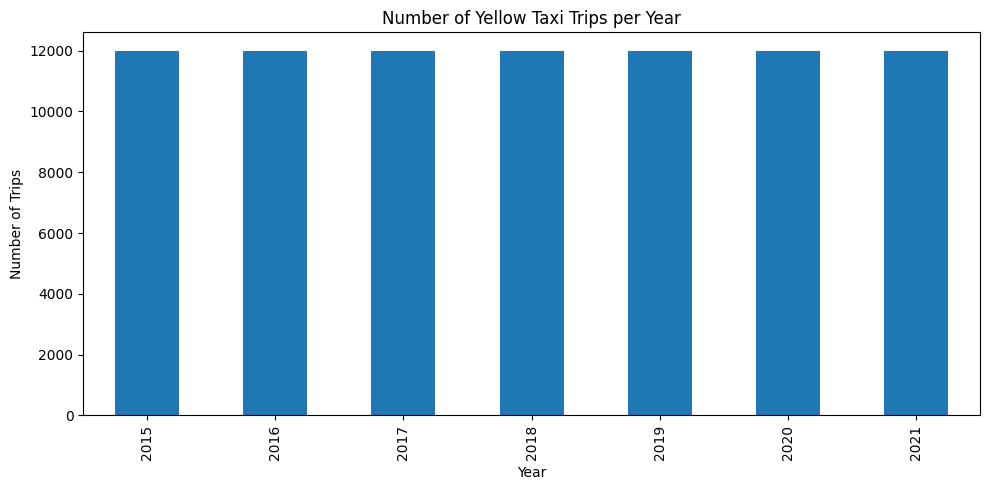

In [17]:
# Balkendiagramm: Anzahl Fahrten pro Jahr.
# Erwartung: 2020 und 2021 sind deutlich tiefer als 2015-2019.

ax = trips_per_year_pd.plot(
    x="file_year",
    y="number_of_trips",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Number of Yellow Taxi Trips per Year"
)

ax.set_xlabel("Year")
ax.set_ylabel("Number of Trips")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_per_year.png", dpi=150)
plt.show()

In [ ]:
Analyse 2 Fahrten pro Monat

In [18]:
# Anzahl Fahrten pro Jahr und Monat berechnen.
# Damit werden saisonale Muster und Einbrüche über die Zeit sichtbar.

trips_per_month = df.groupBy("file_year", "file_month") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("file_year", "file_month")

trips_per_month.show(100)

+---------+----------+---------------+
|file_year|file_month|number_of_trips|
+---------+----------+---------------+
|     2015|         1|           1000|
|     2015|         2|           1000|
|     2015|         3|           1000|
|     2015|         4|           1000|
|     2015|         5|           1000|
|     2015|         6|           1000|
|     2015|         7|           1000|
|     2015|         8|           1000|
|     2015|         9|           1000|
|     2015|        10|           1000|
|     2015|        11|           1000|
|     2015|        12|           1000|
|     2016|         1|           1000|
|     2016|         2|           1000|
|     2016|         3|           1000|
|     2016|         4|           1000|
|     2016|         5|           1000|
|     2016|         6|           1000|
|     2016|         7|           1000|
|     2016|         8|           1000|
|     2016|         9|           1000|
|     2016|        10|           1000|
|     2016|        11|   

In [19]:
# Tabelle in Pandas umwandeln und eine lesbare year_month-Spalte erstellen.

trips_per_month_pd = trips_per_month.toPandas()

trips_per_month_pd["year_month"] = (
    trips_per_month_pd["file_year"].astype(str)
    + "-"
    + trips_per_month_pd["file_month"].astype(str).str.zfill(2)
)

trips_per_month_pd.to_csv(
    f"{RESULT_PATH}/trips_per_month.csv",
    index=False
)

trips_per_month_pd.head()

,file_year,file_month,number_of_trips,year_month
0,2015,1,1000,2015-01
1,2015,2,1000,2015-02
2,2015,3,1000,2015-03
3,2015,4,1000,2015-04
4,2015,5,1000,2015-05


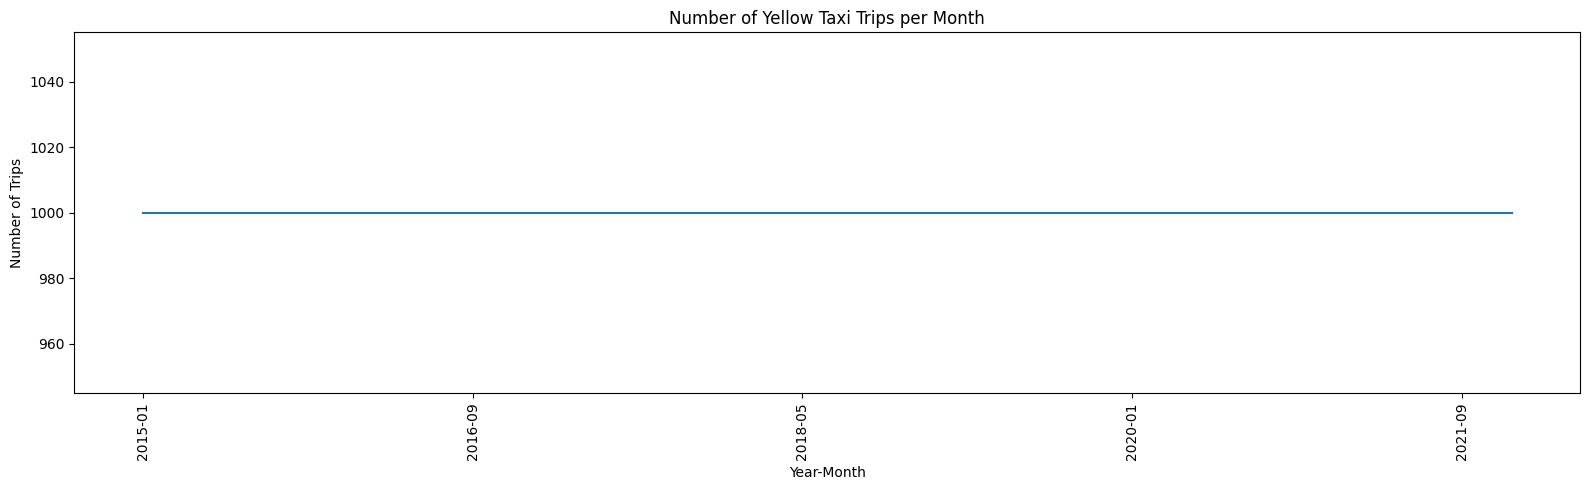

In [20]:
# Liniendiagramm: Anzahl Fahrten pro Monat.
# Dadurch sieht man die zeitliche Entwicklung der Nachfrage.

ax = trips_per_month_pd.plot(
    x="year_month",
    y="number_of_trips",
    kind="line",
    figsize=(16, 5),
    legend=False,
    title="Number of Yellow Taxi Trips per Month"
)

ax.set_xlabel("Year-Month")
ax.set_ylabel("Number of Trips")

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_per_month.png", dpi=150)
plt.show()

In [ ]:
Analyse 3: Fahrten pro Stunde

In [21]:
# Anzahl Fahrten pro Stunde berechnen.
# pickup_hour wurde bereits im Preprocessing aus dem Pickup-Zeitpunkt erstellt.

trips_by_hour = df.groupBy("pickup_hour") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("pickup_hour")

trips_by_hour.show(24)

+-----------+---------------+
|pickup_hour|number_of_trips|
+-----------+---------------+
|          0|           2556|
|          1|           1734|
|          2|           1160|
|          3|            849|
|          4|            639|
|          5|            792|
|          6|           1774|
|          7|           3093|
|          8|           3773|
|          9|           3876|
|         10|           3982|
|         11|           4297|
|         12|           4541|
|         13|           4648|
|         14|           4905|
|         15|           4794|
|         16|           4485|
|         17|           5037|
|         18|           5389|
|         19|           5143|
|         20|           4516|
|         21|           4441|
|         22|           4135|
|         23|           3441|
+-----------+---------------+



In [22]:
# Aggregierte Stunden-Tabelle speichern.

trips_by_hour_pd = trips_by_hour.toPandas()

trips_by_hour_pd.to_csv(
    f"{RESULT_PATH}/trips_by_hour.csv",
    index=False
)

trips_by_hour_pd

,pickup_hour,number_of_trips
0,0,2556
1,1,1734
2,2,1160
3,3,849
4,4,639
5,5,792
6,6,1774
7,7,3093
8,8,3773
9,9,3876


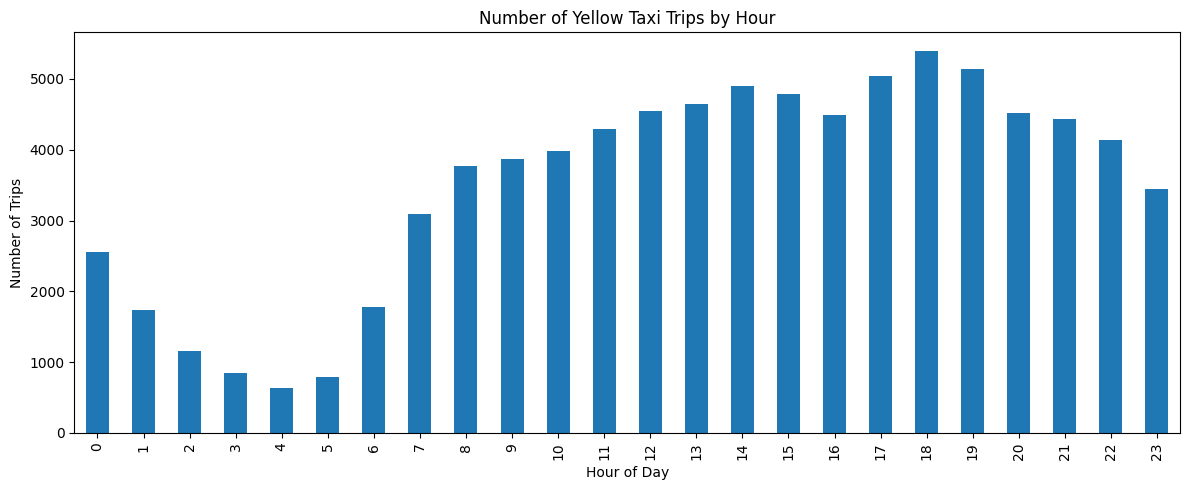

In [23]:
# Balkendiagramm: Anzahl Fahrten pro Stunde.
# Damit wird sichtbar, zu welcher Uhrzeit die Nachfrage am höchsten ist.

ax = trips_by_hour_pd.plot(
    x="pickup_hour",
    y="number_of_trips",
    kind="bar",
    figsize=(12, 5),
    legend=False,
    title="Number of Yellow Taxi Trips by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Number of Trips")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_by_hour.png", dpi=150)
plt.show()

In [24]:
# Die Stunde mit der höchsten Anzahl Fahrten bestimmen.

max_hour = trips_by_hour.orderBy(F.desc("number_of_trips")).limit(1)

max_hour.show()

+-----------+---------------+
|pickup_hour|number_of_trips|
+-----------+---------------+
|         18|           5389|
+-----------+---------------+



In [ ]:
Analyse 4: Fahrten pro Wochentag

In [25]:
# Spark dayofweek:
# 1 = Sunday
# 2 = Monday
# 3 = Tuesday
# 4 = Wednesday
# 5 = Thursday
# 6 = Friday
# 7 = Saturday

df_weekday = df.withColumn(
    "weekday_name",
    F.when(F.col("pickup_weekday") == 1, "Sunday")
     .when(F.col("pickup_weekday") == 2, "Monday")
     .when(F.col("pickup_weekday") == 3, "Tuesday")
     .when(F.col("pickup_weekday") == 4, "Wednesday")
     .when(F.col("pickup_weekday") == 5, "Thursday")
     .when(F.col("pickup_weekday") == 6, "Friday")
     .when(F.col("pickup_weekday") == 7, "Saturday")
)

In [26]:
# Anzahl Fahrten pro Wochentag berechnen.

trips_by_weekday = df_weekday.groupBy("pickup_weekday", "weekday_name") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("pickup_weekday")

trips_by_weekday.show()

+--------------+------------+---------------+
|pickup_weekday|weekday_name|number_of_trips|
+--------------+------------+---------------+
|             1|      Sunday|          10372|
|             2|      Monday|          11040|
|             3|     Tuesday|          12027|
|             4|   Wednesday|          12668|
|             5|    Thursday|          12951|
|             6|      Friday|          12765|
|             7|    Saturday|          12177|
+--------------+------------+---------------+



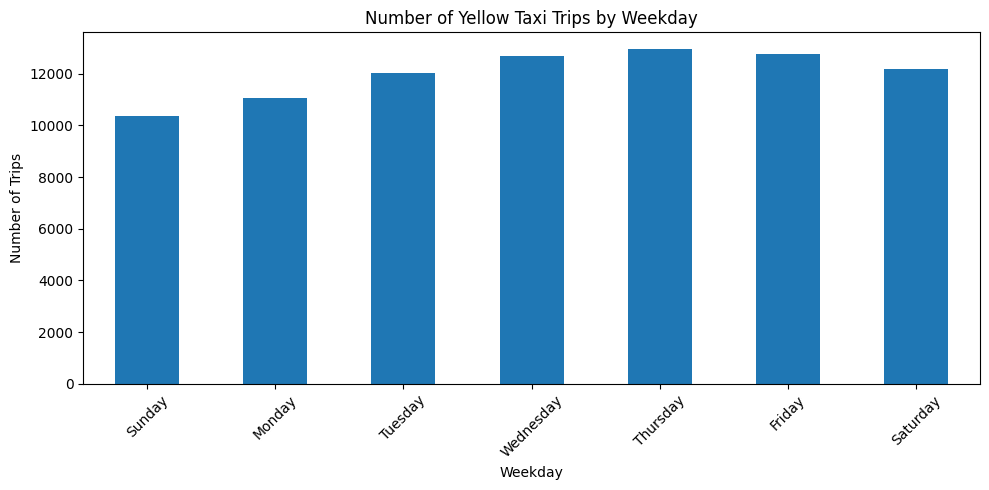

In [27]:
# Tabelle speichern und als Balkendiagramm anzeigen.

trips_by_weekday_pd = trips_by_weekday.toPandas()

trips_by_weekday_pd.to_csv(
    f"{RESULT_PATH}/trips_by_weekday.csv",
    index=False
)

ax = trips_by_weekday_pd.plot(
    x="weekday_name",
    y="number_of_trips",
    kind="bar",
    figsize=(10, 5),
    legend=False,
    title="Number of Yellow Taxi Trips by Weekday"
)

ax.set_xlabel("Weekday")
ax.set_ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_by_weekday.png", dpi=150)
plt.show()

In [ ]:
Analyse 5: Werktag vs. Wochenende

In [28]:
# Neue Kategorie erstellen:
# Weekend = Samstag oder Sonntag
# Weekday = Montag bis Freitag

df_day_type = df_weekday.withColumn(
    "day_type",
    F.when(F.col("pickup_weekday").isin(1, 7), "Weekend")
     .otherwise("Weekday")
)

In [29]:
# Absolute Anzahl Fahrten nach Weekday/Weekend berechnen.
# Wichtig: Dieser Vergleich ist nicht ganz fair, weil es mehr Werktage als Wochenendtage gibt.

trips_by_day_type = df_day_type.groupBy("day_type") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("day_type")

trips_by_day_type.show()

+--------+---------------+
|day_type|number_of_trips|
+--------+---------------+
| Weekday|          61451|
| Weekend|          22549|
+--------+---------------+



In [30]:
# Fairerer Vergleich:
# Nicht nur absolute Anzahl Fahrten, sondern durchschnittliche Fahrten pro Kalendertag.
# Dafür wird zuerst das Pickup-Datum erzeugt.

df_day_type_date = df_day_type.withColumn(
    "pickup_date",
    F.to_date("pickup_datetime")
)

trips_per_calendar_day = df_day_type_date.groupBy("pickup_date", "day_type") \
    .agg(F.count("*").alias("trips_per_day"))

avg_trips_by_day_type = trips_per_calendar_day.groupBy("day_type") \
    .agg(
        F.round(F.avg("trips_per_day"), 2).alias("avg_trips_per_day"),
        F.count("*").alias("number_of_days")
    ) \
    .orderBy("day_type")

avg_trips_by_day_type.show()

+--------+-----------------+--------------+
|day_type|avg_trips_per_day|number_of_days|
+--------+-----------------+--------------+
| Weekday|            33.65|          1826|
| Weekend|            30.89|           730|
+--------+-----------------+--------------+



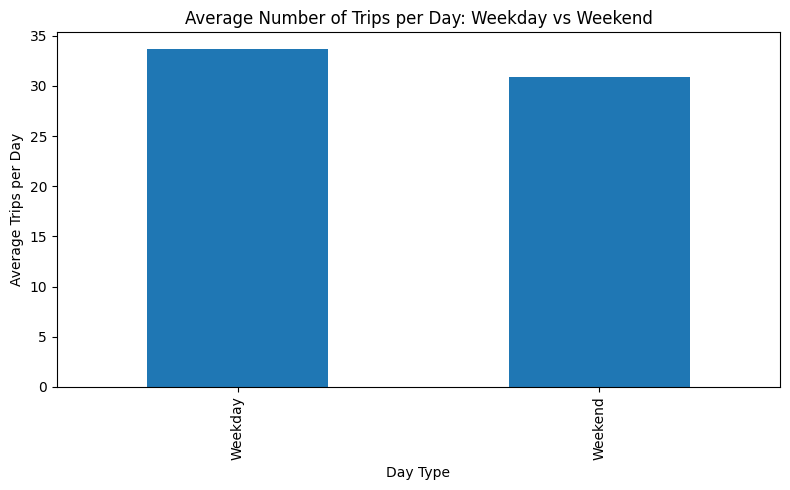

In [31]:
# Durchschnittliche Fahrten pro Tag speichern und visualisieren.

avg_trips_by_day_type_pd = avg_trips_by_day_type.toPandas()

avg_trips_by_day_type_pd.to_csv(
    f"{RESULT_PATH}/avg_trips_by_day_type.csv",
    index=False
)

ax = avg_trips_by_day_type_pd.plot(
    x="day_type",
    y="avg_trips_per_day",
    kind="bar",
    figsize=(8, 5),
    legend=False,
    title="Average Number of Trips per Day: Weekday vs Weekend"
)

ax.set_xlabel("Day Type")
ax.set_ylabel("Average Trips per Day")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/avg_trips_by_day_type.png", dpi=150)
plt.show()

In [ ]:
Analyse 6: Heatmap Wochentag × Uhrzeit

In [32]:
# Anzahl Fahrten nach Wochentag und Stunde berechnen.
# Diese Kombination zeigt besonders gut, wann die Nachfrage am höchsten ist.

trips_weekday_hour = df_weekday.groupBy(
    "pickup_weekday",
    "weekday_name",
    "pickup_hour"
).agg(
    F.count("*").alias("number_of_trips")
).orderBy(
    "pickup_weekday",
    "pickup_hour"
)

trips_weekday_hour.show(200)

+--------------+------------+-----------+---------------+
|pickup_weekday|weekday_name|pickup_hour|number_of_trips|
+--------------+------------+-----------+---------------+
|             1|      Sunday|          0|            544|
|             1|      Sunday|          1|            484|
|             1|      Sunday|          2|            351|
|             1|      Sunday|          3|            288|
|             1|      Sunday|          4|            186|
|             1|      Sunday|          5|             91|
|             1|      Sunday|          6|            114|
|             1|      Sunday|          7|            177|
|             1|      Sunday|          8|            255|
|             1|      Sunday|          9|            351|
|             1|      Sunday|         10|            422|
|             1|      Sunday|         11|            525|
|             1|      Sunday|         12|            611|
|             1|      Sunday|         13|            633|
|             

In [33]:
# Spark-Ergebnis in Pandas umwandeln und als CSV speichern.

trips_weekday_hour_pd = trips_weekday_hour.toPandas()

trips_weekday_hour_pd.to_csv(
    f"{RESULT_PATH}/trips_weekday_hour.csv",
    index=False
)

trips_weekday_hour_pd.head()

,pickup_weekday,weekday_name,pickup_hour,number_of_trips
0,1,Sunday,0,544
1,1,Sunday,1,484
2,1,Sunday,2,351
3,1,Sunday,3,288
4,1,Sunday,4,186


In [34]:
# Pivot-Tabelle erstellen:
# Zeilen = Wochentage
# Spalten = Stunden
# Werte = Anzahl Fahrten

heatmap_data = trips_weekday_hour_pd.pivot(
    index="weekday_name",
    columns="pickup_hour",
    values="number_of_trips"
)

# Reihenfolge der Wochentage korrekt setzen
weekday_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

heatmap_data = heatmap_data.reindex(weekday_order)

heatmap_data

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
weekday_name,,,,,,,,,,,,,,,,,,,,,
Sunday,544,484,351,288,186,91,114,177,255,351,...,662,658,601,590,669,578,440,461,395,286
Monday,196,131,75,57,63,127,286,497,619,547,...,651,683,631,718,767,665,600,580,494,341
Tuesday,221,122,71,45,46,125,330,554,634,631,...,708,689,654,698,766,735,713,655,589,433
Wednesday,279,153,90,60,53,126,324,539,713,664,...,725,735,655,748,817,812,680,721,618,510
Thursday,328,174,103,48,62,107,302,561,633,657,...,731,696,660,783,818,805,763,756,713,590
Friday,406,207,151,106,86,106,275,527,614,598,...,715,689,609,784,806,789,697,653,699,668
Saturday,582,463,319,245,143,110,143,238,305,428,...,713,644,675,716,746,759,623,615,627,613


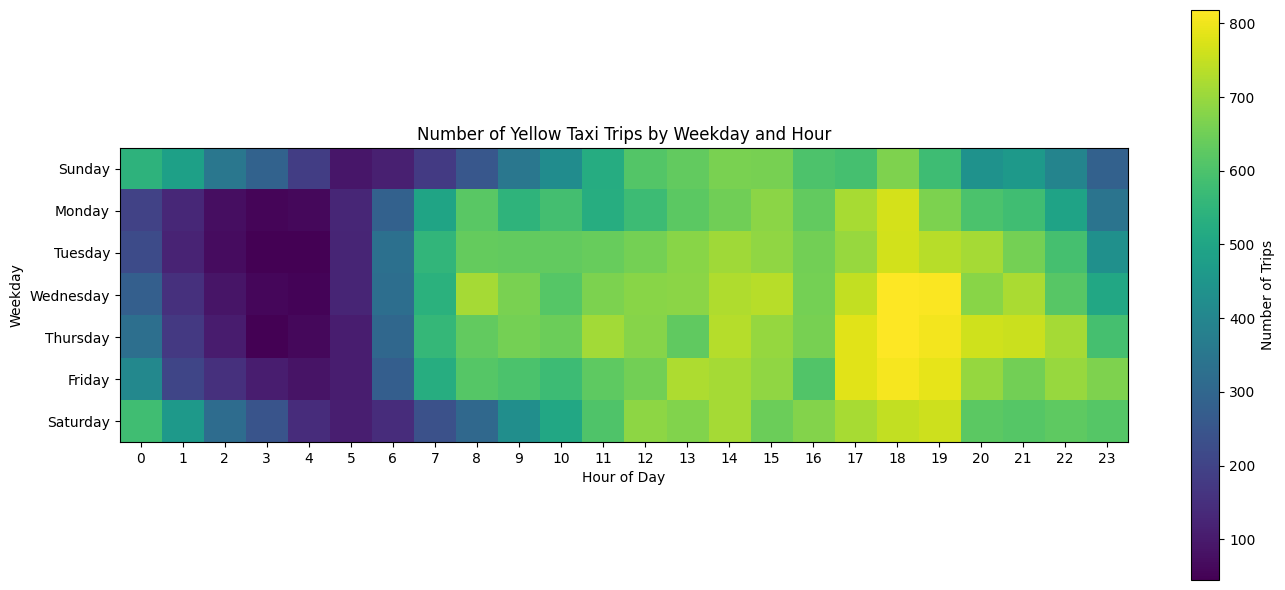

In [35]:
# Heatmap mit matplotlib erstellen.
# Je dunkler/höher der Wert, desto mehr Fahrten gibt es in dieser Kombination aus Wochentag und Stunde.

fig, ax = plt.subplots(figsize=(14, 6))

image = ax.imshow(heatmap_data)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Weekday")
ax.set_title("Number of Yellow Taxi Trips by Weekday and Hour")

plt.colorbar(image, ax=ax, label="Number of Trips")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/heatmap_weekday_hour.png", dpi=150)
plt.show()

In [ ]:
Analyse 7: Vor-Corona vs. Corona-Zeitraum

In [36]:
# 2015-2019 = pre_covid
# 2020-2021 = covid_period
# Damit kann geprüft werden, ob sich die Nachfrageverteilung über den Tag verändert hat.

df_period = df.withColumn(
    "period",
    F.when(F.col("file_year").between(2015, 2019), "2015-2019")
     .when(F.col("file_year").between(2020, 2021), "2020-2021")
)

In [37]:
# Anzahl Fahrten pro Stunde je Periode berechnen.

trips_by_hour_period = df_period.groupBy("period", "pickup_hour") \
    .agg(F.count("*").alias("number_of_trips")) \
    .orderBy("period", "pickup_hour")

trips_by_hour_period.show(100)

+---------+-----------+---------------+
|   period|pickup_hour|number_of_trips|
+---------+-----------+---------------+
|2015-2019|          0|           2119|
|2015-2019|          1|           1469|
|2015-2019|          2|            985|
|2015-2019|          3|            750|
|2015-2019|          4|            557|
|2015-2019|          5|            612|
|2015-2019|          6|           1294|
|2015-2019|          7|           2309|
|2015-2019|          8|           2741|
|2015-2019|          9|           2765|
|2015-2019|         10|           2745|
|2015-2019|         11|           2899|
|2015-2019|         12|           3032|
|2015-2019|         13|           3027|
|2015-2019|         14|           3189|
|2015-2019|         15|           3045|
|2015-2019|         16|           2838|
|2015-2019|         17|           3273|
|2015-2019|         18|           3739|
|2015-2019|         19|           3701|
|2015-2019|         20|           3407|
|2015-2019|         21|           3471|


In [38]:
# Für einen faireren Vergleich wird der Anteil pro Stunde innerhalb der Periode berechnet.
# Sonst würden 2015-2019 wegen mehr Records automatisch dominieren.

period_totals = trips_by_hour_period.groupBy("period") \
    .agg(F.sum("number_of_trips").alias("total_trips_period"))

trips_by_hour_period_pct = trips_by_hour_period.join(
    period_totals,
    on="period",
    how="inner"
).withColumn(
    "percentage_of_period",
    F.round(F.col("number_of_trips") / F.col("total_trips_period") * 100, 4)
).orderBy(
    "period",
    "pickup_hour"
)

trips_by_hour_period_pct.show(100)

+---------+-----------+---------------+------------------+--------------------+
|   period|pickup_hour|number_of_trips|total_trips_period|percentage_of_period|
+---------+-----------+---------------+------------------+--------------------+
|2015-2019|          0|           2119|             60000|              3.5317|
|2015-2019|          1|           1469|             60000|              2.4483|
|2015-2019|          2|            985|             60000|              1.6417|
|2015-2019|          3|            750|             60000|                1.25|
|2015-2019|          4|            557|             60000|              0.9283|
|2015-2019|          5|            612|             60000|                1.02|
|2015-2019|          6|           1294|             60000|              2.1567|
|2015-2019|          7|           2309|             60000|              3.8483|
|2015-2019|          8|           2741|             60000|              4.5683|
|2015-2019|          9|           2765| 

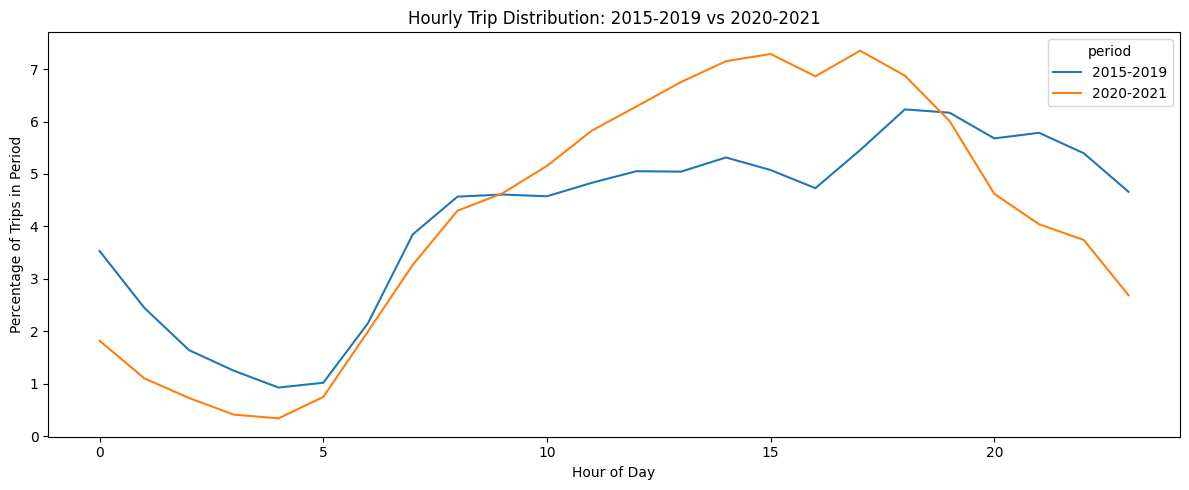

In [39]:
# Tabelle speichern und als Liniendiagramm visualisieren.

trips_by_hour_period_pd = trips_by_hour_period_pct.toPandas()

trips_by_hour_period_pd.to_csv(
    f"{RESULT_PATH}/trips_by_hour_period.csv",
    index=False
)

period_pivot = trips_by_hour_period_pd.pivot(
    index="pickup_hour",
    columns="period",
    values="percentage_of_period"
)

ax = period_pivot.plot(
    kind="line",
    figsize=(12, 5),
    title="Hourly Trip Distribution: 2015-2019 vs 2020-2021"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Percentage of Trips in Period")

plt.tight_layout()
plt.savefig(f"{RESULT_PATH}/trips_by_hour_period.png", dpi=150)
plt.show()